# Thesis figure: T5Gemma2-4B Molweni training loss curve

Parses a SLURM `.out` training log and plots the training loss (per logged step) and
validation ROUGE-L (per epoch) for the T5Gemma2-4B run on Molweni `natural2`
(`5e-6`, e7, b16, new prompt — the link-only-F1 best configuration). Output PNG goes to
the thesis `media/` folder.

Validation loss is parsed but deliberately **not plotted**: nothing in the pipeline
selects on it (`load_best_model_at_end` is disabled in `train.py`, and inference always
loads the final checkpoint), so the thesis does not argue from it.

The logs live under `other-clusters/<cluster>/slurm/logs/`. **Many runs errored out**;
to be safe this notebook (a) globs by run name, (b) keeps only logs that contain the
final `train_runtime` summary line (i.e. the run actually finished), and (c) among those
picks the most recent. Change `RUN_GLOB` to plot a different configuration.

In [1]:
import ast, glob, os, re
import matplotlib.pyplot as plt

LOG_ROOT = "../other-clusters"
OUT = "../../thesis/media/t5gemma2_loss.png"
# e7/b16/new-prompt: this chapter's strongest link-only F1 (84.27)
RUN_GLOB = "**/slurm/logs/*lr5e-6_e7_b16_s2000_molweni_natural2_newprompt.out"

def parse_log(path):
    """Return (train_steps, eval_epochs) as lists of dicts; only if the run finished."""
    train, evals, finished = [], [], False
    for line in open(path, errors="ignore"):
        line = line.strip()
        m = re.search(r"\{[^{}]*\}", line)
        if not m:
            continue
        try:
            d = ast.literal_eval(m.group(0))
        except Exception:
            continue
        if "train_runtime" in d:
            finished = True
        elif "eval_loss" in d:
            evals.append({k: float(v) for k, v in d.items() if _isnum(v)})
        elif "loss" in d:
            train.append({k: float(v) for k, v in d.items() if _isnum(v)})
    return train, evals, finished

def _isnum(v):
    try:
        float(v); return True
    except (TypeError, ValueError):
        return False

candidates = glob.glob(os.path.join(LOG_ROOT, RUN_GLOB), recursive=True)
finished = [(p, *parse_log(p)[:2]) for p in candidates if parse_log(p)[2]]
assert finished, f"no completed run matched {RUN_GLOB}"
path, train, evals = sorted(finished, key=lambda t: os.path.getmtime(t[0]))[-1]
print("using:", os.path.basename(path))
print(f"{len(train)} train points, {len(evals)} eval points")

using: 405134_t5gemma2-4b_lr5e-6_e7_b16_s2000_molweni_natural2_newprompt.out
17 train points, 7 eval points


wrote ../../thesis/media/t5gemma2_loss.png


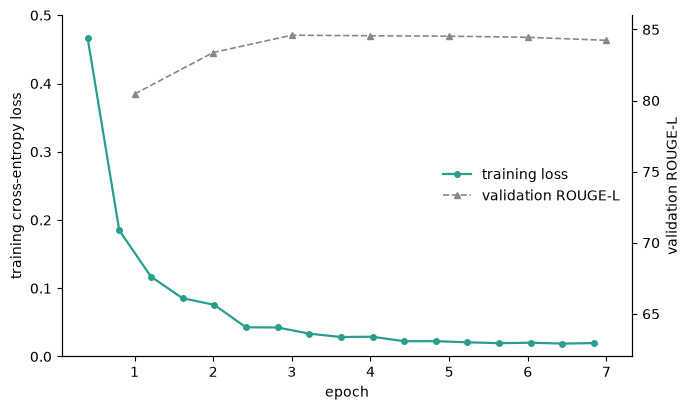

In [2]:
tr_x = [d["epoch"] for d in train]
tr_y = [d["loss"] for d in train]
ev_x = [d["epoch"] for d in evals]
ev_r = [d["eval_rougeL"] for d in evals]

fig, ax1 = plt.subplots(figsize=(7, 4.2))
teal, red, gray = "#2a9d8f", "#e76f51", "#888888"  # red used by the T0-3B cell below

ax1.plot(tr_x, tr_y, "-o", color=teal, ms=4, lw=1.6, label="training loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("training cross-entropy loss")
ax1.set_xticks(range(0, 8))
ax1.spines["top"].set_visible(False)

# right axis: validation ROUGE-L, the per-epoch proxy for task quality
ax2 = ax1.twinx()
ax2.plot(ev_x, ev_r, "--^", color=gray, ms=5, lw=1.2, label="validation ROUGE-L")
ax2.set_ylabel("validation ROUGE-L")
ax2.spines["top"].set_visible(False)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, frameon=False, loc="center right")
ax1.set_ylim(0, 0.5); ax2.set_ylim(62, 86); fig.tight_layout()
fig.savefig(OUT, dpi=150, bbox_inches="tight")
print("wrote", OUT)
plt.show()

## T0-3B baseline loss curve (supplementary — not a thesis figure)

Kept as backup material for the defense rather than for the thesis itself: if anyone
asks why T5Gemma2-4B's validation loss rises, this shows the T0-3B baseline under the
same corpus and decoder, where it falls and flattens instead (1.89 → 1.56, then a 1.4%
uptick at epoch 5). The difference is the capacity-to-data ratio, not a pipeline defect.
This cell does plot validation loss, since that contrast is the whole point of it.

Two things to know about this run. First, it spans **two** log files: the job hit the
SLURM time limit at epoch ~3.9 and was resumed from checkpoint, so the points are
concatenated (the two logs meet cleanly — 3.93 then 4.03, no overlap or gap). Second,
the y-axis is **log-scaled** because the first logged training loss is 62.6; a linear
axis would clip the first third of the run.

Absolute loss values are *not* comparable to the T5Gemma2-4B figure (different tokenizer
and loss normalization) — only the shape of the curves is.

49 train points, 5 eval points


wrote ../../thesis/media/t0_3b_loss.png


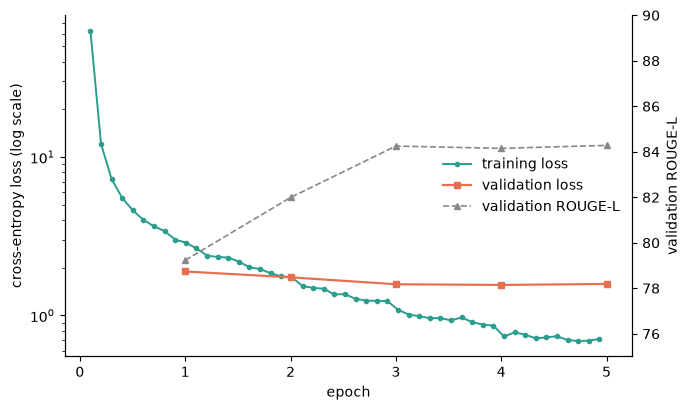

In [3]:
T0_OUT = "../../thesis/media/t0_3b_loss.png"
# preempted at epoch ~3.9 and resumed from checkpoint, so the run spans two logs
T0_LOGS = [
    f"{LOG_ROOT}/fir/slurm/logs/train/train_t0-3b_molweni_natural2_{jid}.out"
    for jid in ("25407609", "25586253")
]

t0_train, t0_evals = [], []
for p in T0_LOGS:
    t, e, _ = parse_log(p)
    t0_train += t
    t0_evals += e
t0_train.sort(key=lambda d: d["epoch"])
t0_evals.sort(key=lambda d: d["epoch"])
assert t0_evals, "no eval points parsed for T0-3B"
print(f"{len(t0_train)} train points, {len(t0_evals)} eval points")

fig, ax1 = plt.subplots(figsize=(7, 4.2))

ax1.plot([d["epoch"] for d in t0_train], [d["loss"] for d in t0_train],
         "-o", color=teal, ms=3, lw=1.4, label="training loss")
ax1.plot([d["epoch"] for d in t0_evals], [d["eval_loss"] for d in t0_evals],
         "-s", color=red, ms=5, lw=1.6, label="validation loss")
ax1.set_yscale("log")
ax1.set_xlabel("epoch")
ax1.set_ylabel("cross-entropy loss (log scale)")
ax1.set_xticks(range(0, 6))
ax1.spines["top"].set_visible(False)

ax2 = ax1.twinx()
ax2.plot([d["epoch"] for d in t0_evals], [d["eval_rougeL"] for d in t0_evals],
         "--^", color=gray, ms=5, lw=1.2, label="validation ROUGE-L")
ax2.set_ylabel("validation ROUGE-L")
ax2.set_ylim(75, 90)
ax2.spines["top"].set_visible(False)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, frameon=False, loc="center right")
fig.tight_layout()
fig.savefig(T0_OUT, dpi=150, bbox_inches="tight")
print("wrote", T0_OUT)
plt.show()